# EDA 6.002: Normalization — clean reference

Load data, keep original, then apply the chosen normalization in three equivalent ways:
1. **Manual** (log vs cap+log per column)
2. **scikit-learn** (ColumnTransformer + CapThenLogTransformer)
3. **TensorFlow** (SteamNormalizer layer)

Final visualization confirms all three match.

## 1. Imports and data load

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from steam_review_ml.data.loaders import load_raw_reviews
from steam_review_ml.data.preprocess import filter_reviews, select_features


def add_review_word_count(temp):
    temp["review_word_count"] = temp["review"].fillna("").apply(lambda x: len(str(x).split()))
    return temp


RAW_PATH = Path("../../data/raw/steam_reviews_full.csv")
df_raw = load_raw_reviews(RAW_PATH, nrows=1_000_000)
df_clean = filter_reviews(df_raw)
df = select_features(df_clean)
df = add_review_word_count(df)
print("Shape:", df.shape)

Shape: (373283, 24)


In [2]:
df.columns

Index(['review_id', 'app_id', 'app_name', 'author.steamid', 'review',
       'recommended', 'votes_helpful', 'author.num_games_owned',
       'author.num_reviews', 'author.playtime_last_two_weeks',
       'author.playtime_at_review', 'votes_funny', 'comment_count',
       'steam_purchase', 'received_for_free', 'written_during_early_access',
       'timestamp_created', 'timestamp_updated', 'author.last_played',
       'is_helpful', 'review_length_chars',
       'author_playtime_last_two_weeks_missing',
       'author_playtime_at_review_missing', 'review_word_count'],
      dtype='str')

## 2. Column definitions

In [3]:
CAP_THEN_LOG_COLS = ["votes_helpful", "author.playtime_last_two_weeks"]
LOG_ONLY_COLS = ["votes_funny", "author.playtime_at_review", "author.num_games_owned", "author.num_reviews", "review_word_count"]
NORM_COLS = CAP_THEN_LOG_COLS + LOG_ONLY_COLS

## 3. Original (kept as reference)

In [4]:
df_original_raw = df[NORM_COLS].copy()
df_original_raw.describe()

,votes_helpful,author.playtime_last_two_weeks,votes_funny,author.playtime_at_review,author.num_games_owned,author.num_reviews,review_word_count
count,373283.000000,373283.000000,3.732830e+05,3.732830e+05,373283.000000,373283.000000,373283.000000
mean,1.460618,76.230217,2.301261e+04,7.555060e+03,160.590539,13.668822,30.023958
std,28.806445,540.969950,9.941574e+06,2.823334e+04,309.123388,40.472369,77.421366
min,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000e+00,5.520000e+02,33.000000,2.000000,3.000000
50%,0.000000,0.000000,0.000000e+00,1.708000e+03,82.000000,5.000000,9.000000
75%,1.000000,0.000000,0.000000e+00,5.890000e+03,180.000000,13.000000,25.000000
max,7352.000000,20924.000000,4.294967e+09,3.062784e+06,20969.000000,5236.000000,2667.000000


## 4. Manual: log vs cap+log

In [5]:
transformed = {}
for col in NORM_COLS:
    data_raw = df[col]
    if col in CAP_THEN_LOG_COLS:
        cap_val = np.percentile(data_raw, 99)
        data_cap = data_raw.clip(upper=cap_val)
        transformed[col] = np.log1p(data_cap)
    else:
        transformed[col] = np.log1p(data_raw)

df_manual = pd.DataFrame(transformed, index=df.index)
df_manual.describe()

,votes_helpful,author.playtime_last_two_weeks,votes_funny,author.playtime_at_review,author.num_games_owned,author.num_reviews,review_word_count
count,373283.000000,373283.000000,373283.000000,373283.000000,373283.000000,373283.000000,373283.000000
mean,0.256175,0.575543,0.092224,7.448884,4.337872,2.000362,2.478302
std,0.509201,1.700466,0.380626,1.752870,1.267242,1.030242,1.241614
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.693147,0.693147
25%,0.000000,0.000000,0.000000,6.315358,3.526361,1.098612,1.386294
50%,0.000000,0.000000,0.000000,7.443664,4.418841,1.791759,2.302585
75%,0.693147,0.000000,0.000000,8.681181,5.198497,2.639057,3.258097
max,2.708050,7.586804,22.180710,14.934835,9.950848,8.563504,7.889084


## 5. scikit-learn implementation

In [6]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer


class CapThenLogTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, percentile=99.0):
        self.percentile = percentile

    def fit(self, X, y=None):
        X = np.asarray(X)
        self.cap_ = np.nanpercentile(X, self.percentile, axis=0)
        if self.cap_.ndim == 0:
            self.cap_ = np.atleast_1d(self.cap_)
        self.n_features_in_ = X.shape[1]
        return self

    def transform(self, X):
        X = np.asarray(X)
        return np.log1p(np.clip(X, None, self.cap_))


ct = ColumnTransformer(
    [
        ("cap_then_log", CapThenLogTransformer(percentile=99.0), CAP_THEN_LOG_COLS),
        ("log_only", FunctionTransformer(np.log1p), LOG_ONLY_COLS),
    ],
    remainder="passthrough",
    verbose_feature_names_out=False,
)
ct.fit(df[NORM_COLS])
arr_sklearn = ct.transform(df[NORM_COLS])
df_sklearn = pd.DataFrame(arr_sklearn, columns=NORM_COLS, index=df.index)
cap_trans = ct.named_transformers_["cap_then_log"]
print("Fitted caps (99th %ile):", dict(zip(CAP_THEN_LOG_COLS, cap_trans.cap_.tolist())))
df_sklearn.describe()

Fitted caps (99th %ile): {'votes_helpful': 14.0, 'author.playtime_last_two_weeks': 1971.0}


,votes_helpful,author.playtime_last_two_weeks,votes_funny,author.playtime_at_review,author.num_games_owned,author.num_reviews,review_word_count
count,373283.000000,373283.000000,373283.000000,373283.000000,373283.000000,373283.000000,373283.000000
mean,0.256175,0.575543,0.092224,7.448884,4.337872,2.000362,2.478302
std,0.509201,1.700466,0.380626,1.752870,1.267242,1.030242,1.241614
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.693147,0.693147
25%,0.000000,0.000000,0.000000,6.315358,3.526361,1.098612,1.386294
50%,0.000000,0.000000,0.000000,7.443664,4.418841,1.791759,2.302585
75%,0.693147,0.000000,0.000000,8.681181,5.198497,2.639057,3.258097
max,2.708050,7.586804,22.180710,14.934835,9.950848,8.563504,7.889084


## 6. TensorFlow implementation

In [7]:
import tensorflow as tf

CAP_P = 0.99
caps = {col: df[col].quantile(CAP_P) for col in CAP_THEN_LOG_COLS}
print("Caps:", caps)

2026-03-12 20:09:21.217941: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-12 20:09:21.224328: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773360561.231278   32154 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773360561.233534   32154 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773360561.239202   32154 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

Caps: {'votes_helpful': np.float64(14.0), 'author.playtime_last_two_weeks': np.float64(1971.0)}


In [8]:
class SteamNormalizer(tf.keras.layers.Layer):
    def __init__(self, caps, cap_then_log_cols, log_only_cols, **kwargs):
        super().__init__(**kwargs)
        self.caps = caps
        self.cap_then_log_cols = cap_then_log_cols
        self.log_only_cols = log_only_cols

    def call(self, inputs):
        x = {k: tf.convert_to_tensor(v) for k, v in inputs.items()}
        for col in self.cap_then_log_cols:
            c = tf.cast(self.caps[col], x[col].dtype)
            x[col] = tf.math.log1p(tf.minimum(x[col], c))
        for col in self.log_only_cols:
            x[col] = tf.math.log1p(x[col])
        return x


norm_layer = SteamNormalizer(
    caps=caps,
    cap_then_log_cols=CAP_THEN_LOG_COLS,
    log_only_cols=LOG_ONLY_COLS,
)
batch = {
    col: tf.constant(df[col].values.reshape(-1, 1), dtype=tf.float32)
    for col in NORM_COLS
}
batch_norm = norm_layer(batch)
df_tf = pd.DataFrame(
    {col: batch_norm[col].numpy().flatten() for col in NORM_COLS},
    index=df.index,
)
df_tf.describe()

I0000 00:00:1773360563.003688   32154 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5199 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070 Laptop GPU, pci bus id: 0000:02:00.0, compute capability: 12.0


,votes_helpful,author.playtime_last_two_weeks,votes_funny,author.playtime_at_review,author.num_games_owned,author.num_reviews,review_word_count
count,373283.000000,373283.000000,373283.000000,373283.000000,373283.000000,373283.000000,373283.000000
mean,0.256175,0.575543,0.092224,7.448884,4.337872,2.000362,2.478302
std,0.509201,1.700467,0.380626,1.752870,1.267242,1.030242,1.241614
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.693147,0.693147
25%,0.000000,0.000000,0.000000,6.315358,3.526361,1.098612,1.386294
50%,0.000000,0.000000,0.000000,7.443664,4.418840,1.791759,2.302585
75%,0.693147,0.000000,0.000000,8.681181,5.198497,2.639057,3.258096
max,2.708050,7.586803,22.180710,14.934835,9.950849,8.563504,7.889084


## 7. Comparison: manual vs sklearn vs TensorFlow

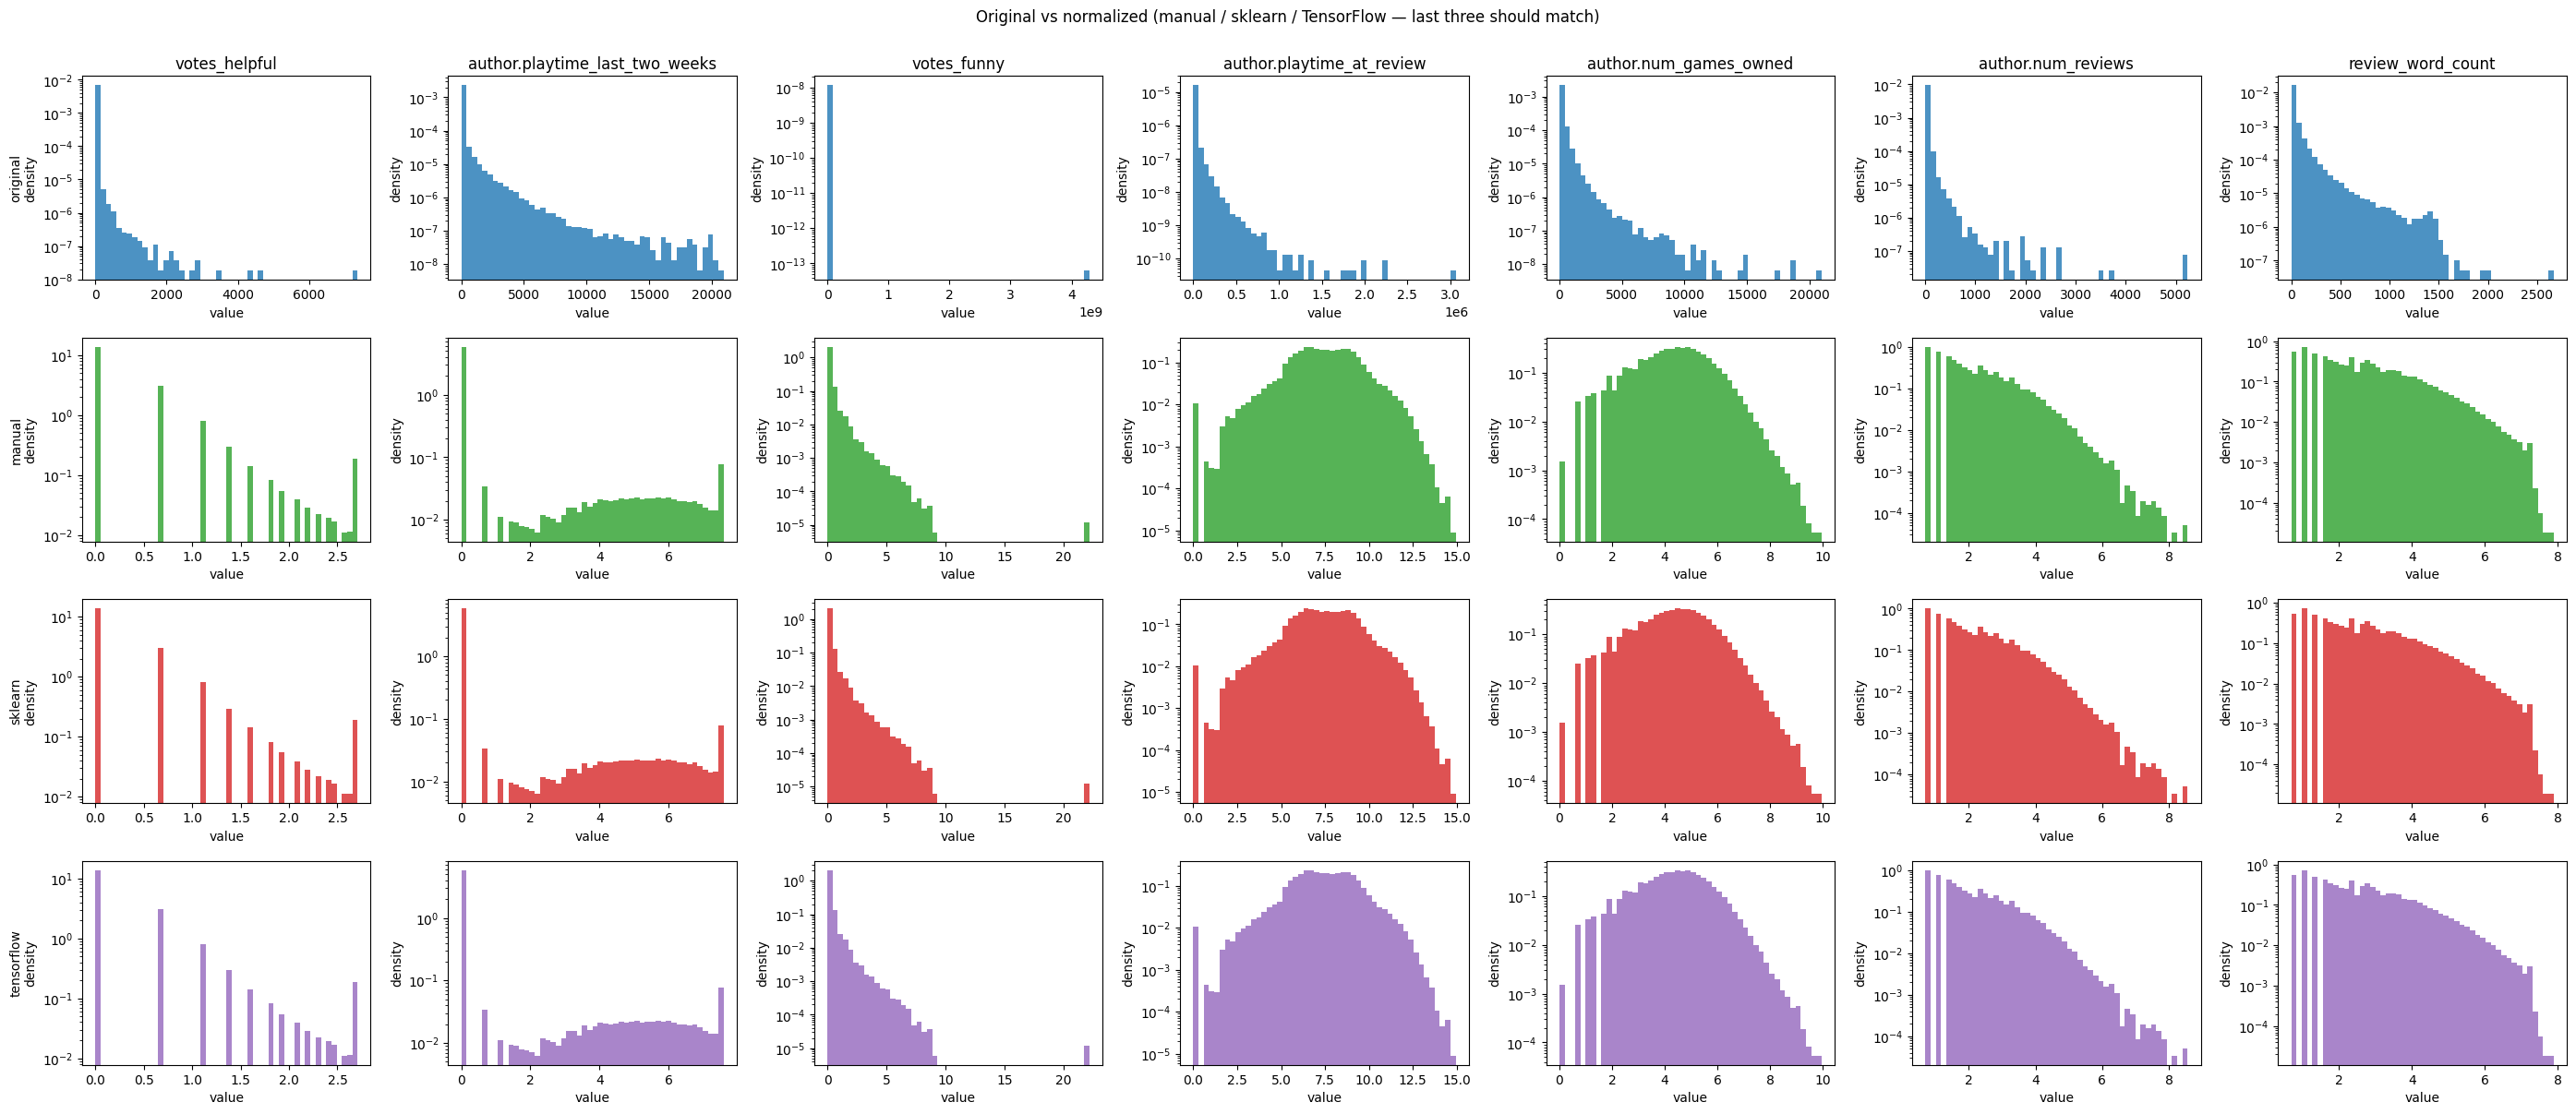

In [9]:
variants = [
    ("original", df_original_raw, "#1f77b4"),
    ("manual", df_manual, "#2ca02c"),
    ("sklearn", df_sklearn, "#d62728"),
    ("tensorflow", df_tf, "#9467bd"),
]
ncols = len(NORM_COLS)
fig, axes = plt.subplots(len(variants), ncols, figsize=(4 * ncols, 3 * len(variants)))
if len(variants) == 1:
    axes = axes.reshape(1, -1)
if ncols == 1:
    axes = axes.reshape(-1, 1)
for i, (label, data, color) in enumerate(variants):
    for j, col in enumerate(NORM_COLS):
        ax = axes[i, j]
        ax.hist(data[col].dropna(), bins=50, alpha=0.8, color=color, density=True, histtype="stepfilled")
        ax.set_yscale("log")
        if i == 0:
            ax.set_title(col)
        if j == 0:
            ax.set_ylabel(f"{label}\ndensity")
        else:
            ax.set_ylabel("density")
for ax in axes.flat:
    ax.set_xlabel("value")
plt.suptitle("Original vs normalized (manual / sklearn / TensorFlow — last three should match)", y=1.002)
plt.tight_layout()
plt.show()

## 8. Sanity check: manual vs sklearn vs TF (numeric)

In [10]:
for col in NORM_COLS:
    ma = df_manual[col].values
    sk = df_sklearn[col].values
    tf_vals = df_tf[col].values
    diff_sk = np.abs(ma - sk).max()
    diff_tf = np.abs(ma - tf_vals).max()
    print(f"{col}: max |manual - sklearn| = {diff_sk:.6f}, max |manual - tf| = {diff_tf:.6f}")

votes_helpful: max |manual - sklearn| = 0.000000, max |manual - tf| = 0.000000
author.playtime_last_two_weeks: max |manual - sklearn| = 0.000000, max |manual - tf| = 0.000000
votes_funny: max |manual - sklearn| = 0.000000, max |manual - tf| = 0.000000
author.playtime_at_review: max |manual - sklearn| = 0.000000, max |manual - tf| = 0.000001
author.num_games_owned: max |manual - sklearn| = 0.000000, max |manual - tf| = 0.000001
author.num_reviews: max |manual - sklearn| = 0.000000, max |manual - tf| = 0.000000
review_word_count: max |manual - sklearn| = 0.000000, max |manual - tf| = 0.000000


In [13]:
df_original_raw.describe()

,votes_helpful,author.playtime_last_two_weeks,votes_funny,author.playtime_at_review,author.num_games_owned,author.num_reviews,review_word_count
count,373283.000000,373283.000000,3.732830e+05,3.732830e+05,373283.000000,373283.000000,373283.000000
mean,1.460618,76.230217,2.301261e+04,7.555060e+03,160.590539,13.668822,30.023958
std,28.806445,540.969950,9.941574e+06,2.823334e+04,309.123388,40.472369,77.421366
min,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000e+00,5.520000e+02,33.000000,2.000000,3.000000
50%,0.000000,0.000000,0.000000e+00,1.708000e+03,82.000000,5.000000,9.000000
75%,1.000000,0.000000,0.000000e+00,5.890000e+03,180.000000,13.000000,25.000000
max,7352.000000,20924.000000,4.294967e+09,3.062784e+06,20969.000000,5236.000000,2667.000000


In [14]:
df_tf.describe()

,votes_helpful,author.playtime_last_two_weeks,votes_funny,author.playtime_at_review,author.num_games_owned,author.num_reviews,review_word_count
count,373283.000000,373283.000000,373283.000000,373283.000000,373283.000000,373283.000000,373283.000000
mean,0.256175,0.575543,0.092224,7.448884,4.337872,2.000362,2.478302
std,0.509201,1.700467,0.380626,1.752870,1.267242,1.030242,1.241614
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.693147,0.693147
25%,0.000000,0.000000,0.000000,6.315358,3.526361,1.098612,1.386294
50%,0.000000,0.000000,0.000000,7.443664,4.418840,1.791759,2.302585
75%,0.693147,0.000000,0.000000,8.681181,5.198497,2.639057,3.258096
max,2.708050,7.586803,22.180710,14.934835,9.950849,8.563504,7.889084
